In [2]:
import pandas as pd

In [4]:
df = pd.read_csv("Combined Data.csv")

In [5]:
df.head()

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  53043 non-null  int64
 1   statement   52681 non-null  str  
 2   status      53043 non-null  str  
dtypes: int64(1), str(2)
memory usage: 30.8 MB


In [8]:
df.isnull().sum()

Unnamed: 0      0
statement     362
status          0
dtype: int64

In [9]:
df = df.dropna(subset=["statement"])

In [10]:
df.isnull().sum()

Unnamed: 0    0
statement     0
status        0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["status"].value_counts()

status
Normal                  16343
Depression              15404
Suicidal                10652
Anxiety                  3841
Bipolar                  2777
Stress                   2587
Personality disorder     1077
Name: count, dtype: int64

In [13]:
df = df.drop(columns=["Unnamed: 0"])

In [14]:
df.head()

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety


In [15]:
df["text_length"] = df["statement"].apply(len)

df["text_length"].describe()

count    52681.000000
mean       578.713863
std        846.269078
min          2.000000
25%         80.000000
50%        317.000000
75%        752.000000
max      32759.000000
Name: text_length, dtype: float64

In [16]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df["clean_text"] = df["statement"].apply(clean_text)

df[["statement", "clean_text"]].head()

,statement,clean_text
0,oh my gosh,oh my gosh
1,"trouble sleeping, confused mind, restless hear...",trouble sleeping confused mind restless heart ...
2,"All wrong, back off dear, forward doubt. Stay ...",all wrong back off dear forward doubt stay in ...
3,I've shifted my focus to something else but I'...,ive shifted my focus to something else but im ...
4,"I'm restless and restless, it's been a month n...",im restless and restless its been a month now ...


In [17]:
X = df["clean_text"]
y = df["status"]

print(X.shape)
print(y.shape)

(52681,)
(52681,)


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(42144,)
(10537,)


In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(42144, 5000)
(10537, 5000)


In [20]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [21]:
y_pred = model.predict(X_test_tfidf)

print(y_pred[:10])

['Normal' 'Normal' 'Bipolar' 'Depression' 'Normal' 'Normal' 'Normal'
 'Normal' 'Depression' 'Depression']


In [22]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7657777355983677


In [23]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

                      precision    recall  f1-score   support

             Anxiety       0.84      0.78      0.81       755
             Bipolar       0.84      0.74      0.79       527
          Depression       0.71      0.73      0.72      3016
              Normal       0.84      0.95      0.89      3308
Personality disorder       0.84      0.45      0.59       237
              Stress       0.71      0.48      0.57       536
            Suicidal       0.68      0.65      0.66      2158

            accuracy                           0.77     10537
           macro avg       0.78      0.68      0.72     10537
        weighted avg       0.76      0.77      0.76     10537



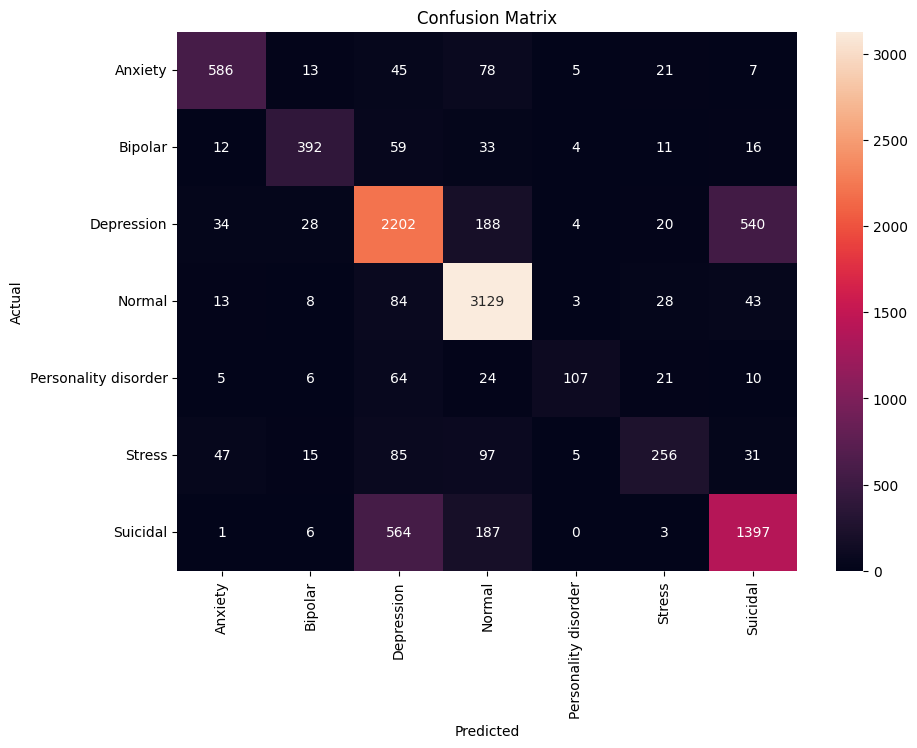

In [24]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [27]:
new_text = ["I feel very tired and hopeless and I don't enjoy things anymore."]

new_text_clean = [clean_text(new_text[0])]
new_text_tfidf = vectorizer.transform(new_text_clean)

prediction = model.predict(new_text_tfidf)

print("Predicted category:", prediction[0])

Predicted category: Depression


In [28]:
import torch
import transformers

print(torch.__version__)
print(transformers.__version__)

C:\Users\mdsih\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2.14.1+cpu
5.18.0


In [29]:
import os

print(os.getcwd())
print(os.listdir())

c:\Users\mdsih\OneDrive\Documents\Kaggle Project\Mental Health Detection
['Combined Data.csv', 'mental_health_detection.ipynb', 'results']


In [30]:
import pandas as pd

df = pd.read_csv("Combined Data.csv")

df = df.dropna(subset=["statement"])
df = df.drop(columns=["Unnamed: 0"])

print(df.shape)

(52681, 2)


In [31]:
from sklearn.preprocessing import LabelEncoder

y = df["status"]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(label_encoder.classes_)

['Anxiety' 'Bipolar' 'Depression' 'Normal' 'Personality disorder' 'Stress'
 'Suicidal']


In [32]:
train_encodings = tokenizer(
    X_train.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    X_test.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

print("Tokenization done!")
print(train_encodings.keys())

NameError: name 'tokenizer' is not defined

In [12]:
import torch
from torch.utils.data import Dataset

class MentalHealthDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }
        item["labels"] = torch.tensor(self.labels[idx])
        return item


train_dataset = MentalHealthDataset(train_encodings, y_train)
test_dataset = MentalHealthDataset(test_encodings, y_test)

print("Train dataset:", len(train_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 42144
Test dataset: 10537


In [33]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=7
)

print("DistilBERT model loaded!")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 766.71it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT model loaded!


In [34]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    logging_steps=100,
    save_strategy="no",
    report_to="none"
)

print("Training settings ready!")

Training settings ready!


In [42]:
import torch
from torch.utils.data import Dataset

class MentalHealthDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }
        item["labels"] = torch.tensor(self.labels[idx])
        return item

print("Class ready!")

Class ready!


In [58]:
train_encodings_small = tokenizer(
    X_train_small.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings_small = tokenizer(
    X_test_small.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

print("Tokenization done!")

Tokenization done!


In [57]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

print("Tokenizer ready!")

Tokenizer ready!


In [59]:
train_encodings_small = tokenizer(
    X_train_small.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings_small = tokenizer(
    X_test_small.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

print("Tokenization done!")

Tokenization done!


In [60]:
train_dataset_small = MentalHealthDataset(
    train_encodings_small,
    y_train_small
)

test_dataset_small = MentalHealthDataset(
    test_encodings_small,
    y_test_small
)

print("Train:", len(train_dataset_small))
print("Test:", len(test_dataset_small))

Train: 240
Test: 60


In [61]:
from transformers import Trainer

trainer_300 = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset_small,
    eval_dataset=test_dataset_small
)

print("Trainer ready!")

Trainer ready!


In [62]:
trainer_300.train()

C:\Users\mdsih\AppData\Roaming\Python\Python314\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss


TrainOutput(global_step=30, training_loss=1.6816828409830729, metrics={'train_runtime': 106.5706, 'train_samples_per_second': 2.252, 'train_steps_per_second': 0.282, 'total_flos': 7948752629760.0, 'train_loss': 1.6816828409830729, 'epoch': 1.0})

In [63]:
results = trainer_300.evaluate()

print(results)

Training Loss,Validation Loss,Step
No log,1.556860,30


{'eval_loss': 1.5568604469299316}


In [65]:
predictions = trainer_300.predict(test_dataset_small)

predicted_labels = predictions.predictions.argmax(axis=1)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test_small, predicted_labels)

print("Transformer Accuracy:", accuracy)

Transformer Accuracy: 0.5666666666666667


In [66]:
new_text = ["I feel very sad, hopeless and tired all the time."]

inputs = tokenizer(
    new_text,
    return_tensors="pt",
    truncation=True,
    padding=True,
    max_length=128
)

with torch.no_grad():
    outputs = model(**inputs)

predicted_id = outputs.logits.argmax(dim=1).item()

predicted_label = label_encoder.inverse_transform([predicted_id])[0]

print("Predicted category:", predicted_label)

Predicted category: Depression
